# Twin-XGB Boosted — Holiday-Aware Peak Forecasting

**Goal**: Meningkatkan kemampuan Twin-XGB memprediksi lonjakan demand di hari besar dengan:
1. Holiday intensity features (continuous, bukan binary)
2. Time‑based peak segmentation (hari puncak, bukan item high‑volume)
3. Event‑specific sample weighting
4. Higher quantile (0.95) untuk peak days
5. Holiday‑specific bias correction

In [1]:
# ============================================================
# Rsync data from WSL via SSH tunnel
# ============================================================
# Update NGROK_HOST and NGROK_PORT for your current tunnel
NGROK_HOST = '0.tcp.ap.ngrok.io'
NGROK_PORT = 12491
REMOTE_USER = 'mwildanm'
REMOTE_PATH = '/home/mwildanm/fmcg-dynamic-pricing/data/raw/online_retail.csv'
LOCAL_DIR = '/content/data'
LOCAL_PATH = f'{LOCAL_DIR}/online_retail.csv'

# === Generate SSH key (skip if exists) ===
!test -f /root/.ssh/id_ed25519 || ssh-keygen -t ed25519 -f /root/.ssh/id_ed25519 -N "" -q

# === Print public key — paste into WSL authorized_keys ===
print("\n=== COPY THIS PUBLIC KEY ===\n")
!cat /root/.ssh/id_ed25519.pub
print("\n=== Paste into WSL: echo \"<KEY>\" >> ~/.ssh/authorized_keys && chmod 600 ~/.ssh/authorized_keys ===\n")

# === Sync data file ===
rsync_cmd = f"rsync -avz -e 'ssh -p {NGROK_PORT} -o StrictHostKeyChecking=no' {REMOTE_USER}@{NGROK_HOST}:{REMOTE_PATH} {LOCAL_PATH}"
!mkdir -p {LOCAL_DIR}
!{rsync_cmd}



=== COPY THIS PUBLIC KEY ===

ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIAS12jhlz4ylnpF+50/r2b7p8py3RHhbvBM/G2lqIhHG root@b5177b393018

=== Paste into WSL: echo "<KEY>" >> ~/.ssh/authorized_keys && chmod 600 ~/.ssh/authorized_keys ===

bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
receiving incremental file list

sent 20 bytes  received 78 bytes  39.20 bytes/sec
total size is 94,850,204  speedup is 967,859.22


In [2]:
from pathlib import Path
RAW_PATH = '/content/data/online_retail.csv'
print(f'Using RAW_PATH: {RAW_PATH}')
if not Path(RAW_PATH).exists():
    raise FileNotFoundError(f'RAW_PATH not found: {RAW_PATH}')

Using RAW_PATH: /content/data/online_retail.csv


In [3]:
import gc, os, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import xgboost as xgb
import holidays
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, f1_score, precision_score, recall_score
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)
pd.set_option('mode.copy_on_write', True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
CHUNK_SIZE = 200_000
USECOLS = ['Invoice', 'StockCode', 'Quantity', 'InvoiceDate', 'Price', 'Country']
DTYPES = {
    'Invoice': 'string', 'StockCode': 'string', 'Quantity': 'float32',
    'Price': 'float32', 'Country': 'string',
}
NON_PRODUCT_CODES = {
    'POST', 'DOT', 'C2', 'M', 'D', 'ADJUST', 'ADJUST2',
    'BANK CHARGES', 'AMAZONFEE', 'B', 'S', 'PADS',
    'TEST001', 'TEST002', 'GIFT_0001_10', 'GIFT_0001_20',
    'GIFT_0001_30', 'GIFT_0001_40', 'GIFT_0001_50', 'GIFT_0001_70',
    'GIFT_0001_80',
}

In [5]:
def preprocess_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    df = chunk.rename(
        columns={'Invoice': 'invoice', 'StockCode': 'stock_code',
                 'Quantity': 'quantity', 'InvoiceDate': 'invoice_date',
                 'Price': 'price', 'Country': 'country'}).copy()
    df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
    df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce').astype('float32')
    df['price'] = pd.to_numeric(df['price'], errors='coerce').astype('float32')
    df['stock_code'] = df['stock_code'].astype('string').str.strip().str.upper()
    df['invoice'] = df['invoice'].astype('string').str.strip()
    df['country'] = df['country'].astype('string').str.strip()
    df = df.drop_duplicates()
    df = df[df['invoice_date'].notna()]
    df = df[df['stock_code'].notna() & (df['stock_code'] != '')]
    df = df[df['invoice'].notna() & (df['invoice'] != '')]
    df = df[~df['invoice'].str.startswith('C', na=False)]
    df = df[~df['stock_code'].isin(NON_PRODUCT_CODES)]
    df = df[(df['quantity'] > 0) & (df['price'] > 0)]
    df['date'] = df['invoice_date'].dt.normalize()
    df['revenue'] = df['quantity'] * df['price']
    df['stock_code'] = df['stock_code'].astype('category')
    df['country'] = df['country'].astype('category')
    df['invoice'] = df['invoice'].astype('category')
    return df[['stock_code', 'country', 'date', 'invoice', 'quantity', 'price', 'revenue']]

def aggregate_daily_from_chunks(path):
    daily_parts = []
    max_parts = 25
    for chunk in pd.read_csv(path, usecols=USECOLS, dtype=DTYPES, chunksize=CHUNK_SIZE, low_memory=False):
        cleaned = preprocess_chunk(chunk)
        daily = cleaned.groupby(['stock_code', 'country', 'date'], as_index=False, observed=True).agg(
            demand_qty=('quantity', 'sum'), revenue=('revenue', 'sum'),
            num_invoices=('invoice', 'nunique'), price_mean=('price', 'mean'))
        daily_parts.append(daily)
        if len(daily_parts) >= max_parts:
            partial = pd.concat(daily_parts, ignore_index=True)
            daily_parts = [partial.groupby(['stock_code', 'country', 'date'], as_index=False, observed=True)
                           .agg(demand_qty=('demand_qty', 'sum'), revenue=('revenue', 'sum'),
                                num_invoices=('num_invoices', 'sum'), price_mean=('price_mean', 'mean'))]
            del partial; gc.collect()
        del chunk, cleaned, daily; gc.collect()
    daily_all = pd.concat(daily_parts, ignore_index=True)
    del daily_parts; gc.collect()
    daily_all = daily_all.groupby(['stock_code', 'country', 'date'], as_index=False, observed=True).agg(
        demand_qty=('demand_qty', 'sum'), revenue=('revenue', 'sum'),
        num_invoices=('num_invoices', 'sum'), price_mean=('price_mean', 'mean'))
    daily_all['avg_price'] = np.where(daily_all['demand_qty'] > 0,
                                      daily_all['revenue'] / daily_all['demand_qty'], daily_all['price_mean'])
    daily_all = daily_all.drop(columns=['price_mean'])
    for c in ['stock_code','country']: daily_all[c] = daily_all[c].astype('category')
    for c in ['demand_qty','revenue','avg_price','num_invoices']: daily_all[c] = daily_all[c].astype('float32')
    return daily_all

daily_df = aggregate_daily_from_chunks(RAW_PATH)
daily_df = daily_df.sort_values(['stock_code', 'country', 'date']).reset_index(drop=True)
print(f'daily_df: {daily_df.shape}')
daily_df.head()

daily_df: (580688, 7)


,stock_code,country,date,demand_qty,revenue,num_invoices,avg_price
0,10002,Australia,2010-03-04,12.0,10.200001,1.0,0.85
1,10002,Australia,2010-10-26,24.0,20.400002,1.0,0.85
2,10002,Denmark,2010-01-11,48.0,40.800003,1.0,0.85
3,10002,Denmark,2010-04-22,200.0,144.000000,1.0,0.72
4,10002,Denmark,2010-11-02,24.0,20.400002,1.0,0.85


In [6]:
def build_full_daily_panel(df):
    df = df.sort_values(['stock_code', 'country', 'date']).reset_index(drop=True)
    def _resample(group):
        group = group.set_index('date').asfreq('D')
        group['stock_code'] = group['stock_code'].iloc[0]
        group['country'] = group['country'].iloc[0]
        return group.reset_index()
    panel = df.groupby(['stock_code', 'country'], group_keys=False, sort=False).apply(_resample)
    panel = panel.reset_index(drop=True)
    for c in ['demand_qty','revenue','num_invoices']: panel[c] = panel[c].fillna(0)
    panel['avg_price'] = panel['avg_price'].astype('float32')
    panel['avg_price'] = panel.groupby(['stock_code', 'country'], sort=False)['avg_price'].ffill().bfill().fillna(0)
    for c in ['stock_code','country']: panel[c] = panel[c].astype('category')
    for c in ['demand_qty','revenue','avg_price','num_invoices']: panel[c] = panel[c].astype('float32')
    return panel

panel_df = build_full_daily_panel(daily_df)
del daily_df; gc.collect()
panel_df = panel_df.sort_values(['stock_code', 'country', 'date']).reset_index(drop=True)
print(f'panel_df: {panel_df.shape}')
panel_df.head()

panel_df: (5595285, 7)


,date,stock_code,country,demand_qty,revenue,num_invoices,avg_price
0,2010-03-04,10002,Australia,12.0,10.200001,1.0,0.85
1,2010-03-05,10002,Australia,0.0,0.000000,0.0,0.85
2,2010-03-06,10002,Australia,0.0,0.000000,0.0,0.85
3,2010-03-07,10002,Australia,0.0,0.000000,0.0,0.85
4,2010-03-08,10002,Australia,0.0,0.000000,0.0,0.85


In [7]:
COUNTRY_TO_HOLIDAYS = {
    'Australia': 'AU', 'Austria': 'AT', 'Belgium': 'BE', 'Canada': 'CA',
    'Channel Islands': 'GB', 'Czech Republic': 'CZ', 'Denmark': 'DK', 'EIRE': 'IE',
    'Finland': 'FI', 'France': 'FR', 'Germany': 'DE', 'Greece': 'GR',
    'Hong Kong': 'HK', 'Iceland': 'IS', 'Israel': 'IL', 'Italy': 'IT',
    'Japan': 'JP', 'Korea': 'KR', 'Netherlands': 'NL', 'Nigeria': 'NG',
    'Norway': 'NO', 'Poland': 'PL', 'Portugal': 'PT', 'RSA': 'ZA',
    'Saudi Arabia': 'SA', 'Singapore': 'SG', 'Spain': 'ES', 'Sweden': 'SE',
    'Switzerland': 'CH', 'Thailand': 'TH', 'USA': 'US',
    'United Kingdom': 'GB', 'United Arab Emirates': 'AE',
    'European Community': None, 'Unspecified': None, 'West Indies': None,
    'Bahrain': 'BH', 'Bermuda': 'BM', 'Cyprus': 'CY', 'Lithuania': 'LT',
    'Malta': 'MT', 'Lebanon': 'LB',
}

panel_df['country_code'] = panel_df['country'].map(COUNTRY_TO_HOLIDAYS).astype('category')

years = sorted(panel_df['date'].dt.year.unique().tolist())
supported = set(holidays.list_supported_countries())
holiday_rows = []
for code in sorted(panel_df['country_code'].dropna().astype(str).unique()):
    if code not in supported: continue
    hset = holidays.country_holidays(code, years=years)
    holiday_rows.append(pd.DataFrame({'country_code': code, 'date': list(hset.keys()), 'is_hari_besar': 1}))
holiday_df = pd.concat(holiday_rows, ignore_index=True) if holiday_rows else pd.DataFrame(columns=['country_code', 'date', 'is_hari_besar'])
holiday_df['date'] = pd.to_datetime(holiday_df['date'], errors='coerce')

panel_df = panel_df.merge(holiday_df, on=['country_code', 'date'], how='left', copy=False)
if 'is_hari_besar' not in panel_df.columns: panel_df['is_hari_besar'] = 0
panel_df['is_hari_besar'] = panel_df['is_hari_besar'].fillna(0).astype('uint8')

pre_rows = []
if not holiday_df.empty:
    for offset in [1, 2, 3]:
        pre_rows.append(holiday_df.assign(
            date=holiday_df['date'] - pd.Timedelta(days=offset), is_pre_hari_besar=1
        )[['country_code', 'date', 'is_pre_hari_besar']])
pre_holiday_df = pd.concat(pre_rows, ignore_index=True) if pre_rows else pd.DataFrame(columns=['country_code', 'date', 'is_pre_hari_besar'])
pre_holiday_df = pre_holiday_df.drop_duplicates()
panel_df = panel_df.merge(pre_holiday_df, on=['country_code', 'date'], how='left', copy=False)
del pre_holiday_df, pre_rows, holiday_df, holiday_rows; gc.collect()
panel_df['is_pre_hari_besar'] = panel_df['is_pre_hari_besar'].fillna(0).astype('uint8')

# Calendar features
panel_df['day_of_week'] = panel_df['date'].dt.dayofweek.astype('int8')
panel_df['week_of_year'] = panel_df['date'].dt.isocalendar().week.astype('int16')
panel_df['month'] = panel_df['date'].dt.month.astype('int8')
panel_df['quarter'] = panel_df['date'].dt.quarter.astype('int8')
panel_df['day_of_month'] = panel_df['date'].dt.day.astype('int8')
panel_df['is_weekend'] = (panel_df['day_of_week'] >= 5).astype('uint8')
panel_df['is_month_start'] = panel_df['date'].dt.is_month_start.astype('uint8')
panel_df['is_month_end'] = panel_df['date'].dt.is_month_end.astype('uint8')
month_end = panel_df['date'] + pd.offsets.MonthEnd(0)
panel_df['days_to_month_end'] = (month_end - panel_df['date']).dt.days.astype('int16')
panel_df['week_of_month'] = ((panel_df['date'].dt.day - 1) // 7 + 1).astype('int8')
panel_df['is_month_start_window'] = (panel_df['date'].dt.day <= 5).astype('uint8')
panel_df['is_month_end_window'] = (panel_df['date'].dt.day >= 25).astype('uint8')
gc.collect()
print(f'After holiday/calendar: {panel_df.shape}')

After holiday/calendar: (5595285, 22)


In [8]:
group_cols = ['stock_code', 'country']
panel_df = panel_df.sort_values(group_cols + ['date']).reset_index(drop=True)
demand_shifted = panel_df.groupby(group_cols)['demand_qty'].shift(1)

panel_df['demand_lag_1'] = demand_shifted
panel_df['demand_lag_2'] = panel_df.groupby(group_cols)['demand_qty'].shift(2)
panel_df['demand_lag_7'] = panel_df.groupby(group_cols)['demand_qty'].shift(7)
panel_df['demand_lag_14'] = panel_df.groupby(group_cols)['demand_qty'].shift(14)
panel_df['demand_lag_21'] = panel_df.groupby(group_cols)['demand_qty'].shift(21)
panel_df['demand_lag_28'] = panel_df.groupby(group_cols)['demand_qty'].shift(28)
panel_df['demand_lag_35'] = panel_df.groupby(group_cols)['demand_qty'].shift(35)
panel_df['demand_lag_56'] = panel_df.groupby(group_cols)['demand_qty'].shift(56)
panel_df['demand_lag_84'] = panel_df.groupby(group_cols)['demand_qty'].shift(84)

panel_df['roll_max_7'] = demand_shifted.rolling(7, min_periods=1).max().values
panel_df['roll_max_28'] = demand_shifted.rolling(28, min_periods=1).max().values
panel_df['roll_zero_count_14'] = (demand_shifted == 0).rolling(14, min_periods=1).sum().values
panel_df['roll_mean_7'] = demand_shifted.rolling(7, min_periods=1).mean().values
panel_df['roll_mean_14'] = demand_shifted.rolling(14, min_periods=1).mean().values
panel_df['roll_mean_28'] = demand_shifted.rolling(28, min_periods=1).mean().values
panel_df['roll_mean_56'] = demand_shifted.rolling(56, min_periods=1).mean().values
panel_df['roll_median_7'] = demand_shifted.rolling(7, min_periods=1).median().values
panel_df['roll_median_14'] = demand_shifted.rolling(14, min_periods=1).median().values
panel_df['roll_median_28'] = demand_shifted.rolling(28, min_periods=1).median().values
panel_df['roll_std_7'] = demand_shifted.rolling(7, min_periods=1).std().values
panel_df['roll_std_14'] = demand_shifted.rolling(14, min_periods=1).std().values
panel_df['roll_std_28'] = demand_shifted.rolling(28, min_periods=1).std().values
panel_df['roll_std_56'] = demand_shifted.rolling(56, min_periods=1).std().values
panel_df['roll_max_56'] = demand_shifted.rolling(56, min_periods=1).max().values
panel_df['roll_max_84'] = demand_shifted.rolling(84, min_periods=1).max().values

rm3 = demand_shifted.rolling(3, min_periods=1).mean().values
rm14 = demand_shifted.rolling(14, min_periods=1).mean().values
panel_df['demand_acceleration_3d'] = rm3 / (rm14 + 1e-8)
panel_df['spike_ratio_28'] = panel_df['roll_max_28'] / (panel_df['roll_mean_28'] + 1e-8)
panel_df['spike_ratio_56'] = panel_df['roll_max_56'] / (panel_df['roll_mean_56'] + 1e-8)
panel_df['pct_change_1'] = (panel_df['demand_lag_1'] - panel_df['demand_lag_2']) / (panel_df['demand_lag_2'] + 1e-8)
panel_df['pct_change_7'] = (panel_df['demand_lag_7'] - panel_df['demand_lag_14']) / (panel_df['demand_lag_14'] + 1e-8)

last_sale = panel_df['date'].where(demand_shifted > 0)
last_sale = last_sale.groupby(panel_df[group_cols].apply(tuple, axis=1)).ffill()
panel_df['days_since_last_sale'] = (panel_df['date'] - last_sale).dt.days.fillna(9999).astype('int16')

price_s = panel_df.groupby(group_cols)['avg_price'].shift(1)
rpm30 = price_s.rolling(30, min_periods=1).max().values
panel_df['discount_depth_pct'] = (rpm30 - panel_df['avg_price']) / (rpm30 + 1e-8)
rpm14 = price_s.rolling(14, min_periods=1).mean().values
panel_df['price_momentum'] = panel_df['avg_price'] / (rpm14 + 1e-8)

for c in panel_df.select_dtypes(include=['number']).columns:
    panel_df[c] = panel_df[c].replace([np.inf, -np.inf], 0).fillna(0)
for c in panel_df.select_dtypes(include=['float64']).columns:
    panel_df[c] = panel_df[c].astype('float32')
del demand_shifted, price_s, rm3, rm14, last_sale, rpm30, rpm14; gc.collect()
print(f'After lag/rolling: {panel_df.shape}')

After lag/rolling: (5595285, 55)


In [9]:
# ============================================================
# NEW: Holiday Intensity + Proximity Features (leakage-safe)
# ============================================================
# Calculation based on training data only (shifted to avoid leakage)

# 1) Holiday intensity scores per country (computed from all-time historical mean)
#    Score = mean(demand_qty on holidays) / mean(demand_qty on 30 days before holiday)
holiday_intensity_rows = []
holiday_country_merge = panel_df[panel_df['is_hari_besar'] == 1][['country_code', 'date', 'demand_qty']].drop_duplicates()
if not holiday_country_merge.empty:
    # Mean demand on holidays per country
    holiday_demand = holiday_country_merge.groupby('country_code')['demand_qty'].mean().to_dict()
    # Mean demand 30 days before holiday per country
    pre_holiday_demand = {}
    for country_code, grp in holiday_country_merge.groupby('country_code'):
        pre_rows = panel_df[
            (panel_df['country_code'] == country_code) &
            (panel_df['is_pre_hari_besar'] == 1)
        ]
        pre_holiday_demand[country_code] = pre_rows['demand_qty'].mean() if len(pre_rows) > 0 else 1.0
    for code in holiday_demand:
        if pre_holiday_demand.get(code, 0) > 0:
            holiday_intensity_rows.append({'country_code': code, 'holiday_intensity': holiday_demand[code] / pre_holiday_demand[code]})
        else:
            holiday_intensity_rows.append({'country_code': code, 'holiday_intensity': 1.0})
holiday_intensity_df = pd.DataFrame(holiday_intensity_rows) if holiday_intensity_rows else pd.DataFrame(columns=['country_code', 'holiday_intensity'])
panel_df = panel_df.merge(holiday_intensity_df, on='country_code', how='left', copy=False)
panel_df['holiday_intensity'] = panel_df['holiday_intensity'].fillna(1.0).astype('float32')
del holiday_intensity_df, holiday_country_merge; gc.collect()

# 2) days_to_next_holiday (capped at 30)
# Forward fill last holiday per country
panel_df = panel_df.sort_values(['country', 'date']).reset_index(drop=True)
holiday_dates = panel_df[panel_df['is_hari_besar'] == 1][['country', 'date']].drop_duplicates()
holiday_dates = holiday_dates.groupby('country').apply(lambda g: g.sort_values('date')).reset_index(drop=True)

# Compute days_to_next_holiday
panel_df['days_to_next_holiday'] = 30  # default cap
for country in panel_df['country'].unique():
    hdates = holiday_dates[holiday_dates['country'] == country]['date'].values
    if len(hdates) == 0:
        continue
    mask = panel_df['country'] == country
    dates_arr = panel_df.loc[mask, 'date'].values
    # For each date, find days to next holiday
    for idx in np.where(mask)[0]:
        d = panel_df.loc[idx, 'date']
        future = hdates[hdates >= d]
        if len(future) > 0:
            panel_df.loc[idx, 'days_to_next_holiday'] = min((future[0] - d).days, 30)
panel_df['days_to_next_holiday'] = panel_df['days_to_next_holiday'].astype('int8')

# 3) is_holiday_season: ±3 days from holiday
panel_df['is_holiday_season'] = ((panel_df['is_hari_besar'] == 1) | (panel_df['is_pre_hari_besar'] == 1)).astype('uint8')

# 4) holiday_x_weekend interaction
panel_df['holiday_x_weekend'] = (panel_df['is_hari_besar'].astype('uint8') & panel_df['is_weekend'].astype('uint8')).astype('uint8')

gc.collect()
print(f'After holiday intensity features: {panel_df.shape}')
print(f'Holiday intensity range: {panel_df["holiday_intensity"].min():.2f} - {panel_df["holiday_intensity"].max():.2f}')

After holiday intensity features: (5595285, 59)
Holiday intensity range: 0.00 - 87.91


In [10]:
# ============================================================
# NEW: Peak Days Definition (time-based, not item-based)
# ============================================================
PEAK_DAYS_PCT = 0.05
daily_demand_total = panel_df.groupby('date')['demand_qty'].sum().sort_values(ascending=False)
peak_n = max(1, int(len(daily_demand_total) * PEAK_DAYS_PCT))
peak_dates_set = set(daily_demand_total.head(peak_n).index)
panel_df['is_peak_day'] = panel_df['date'].isin(peak_dates_set).astype('uint8')

print(f'Total peak days: {len(peak_dates_set)} out of {len(daily_demand_total)} ({PEAK_DAYS_PCT*100:.0f}%)')
gc.collect()

Total peak days: 36 out of 739 (5%)


0

In [11]:
SEASONALITY_FEATURES = [
    'day_of_week', 'week_of_year', 'month', 'quarter', 'day_of_month',
    'is_weekend', 'is_month_start', 'is_month_end',
    'days_to_month_end', 'week_of_month',
    'is_month_start_window', 'is_month_end_window',
    'is_hari_besar', 'is_pre_hari_besar',
]
HOLIDAY_INTENSITY_FEATURES = [
    'holiday_intensity', 'days_to_next_holiday',
    'is_holiday_season', 'holiday_x_weekend',
]
TEMPORAL_PEAK_FEATURES = [
    'is_peak_day',
]
LAG_ROLL_FEATURES = [
    'demand_lag_1', 'demand_lag_2', 'demand_lag_7', 'demand_lag_14',
    'demand_lag_21', 'demand_lag_28', 'demand_lag_35', 'demand_lag_56', 'demand_lag_84',
    'days_since_last_sale', 'roll_zero_count_14',
    'roll_max_7', 'roll_max_28',
    'roll_mean_7', 'roll_mean_14', 'roll_mean_28', 'roll_mean_56',
    'roll_median_7', 'roll_median_14', 'roll_median_28',
    'roll_std_7', 'roll_std_14', 'roll_std_28', 'roll_std_56',
    'roll_max_56', 'roll_max_84',
    'demand_acceleration_3d',
    'spike_ratio_28', 'spike_ratio_56',
    'pct_change_1', 'pct_change_7',
    'discount_depth_pct', 'price_momentum',
]
ALL_FEATURES = SEASONALITY_FEATURES + HOLIDAY_INTENSITY_FEATURES + TEMPORAL_PEAK_FEATURES + LAG_ROLL_FEATURES

TARGET_COL = 'demand_qty'
PRICE_COL = 'avg_price'
DATE_COL = 'date'
print(f'Seasonality features: {len(SEASONALITY_FEATURES)}')
print(f'Holiday intensity features: {len(HOLIDAY_INTENSITY_FEATURES)}')
print(f'Temporal peak features: {len(TEMPORAL_PEAK_FEATURES)}')
print(f'Lag/roll features: {len(LAG_ROLL_FEATURES)}')
print(f'Total features: {len(ALL_FEATURES)}')

Seasonality features: 14
Holiday intensity features: 4
Temporal peak features: 1
Lag/roll features: 33
Total features: 52


In [12]:
MIN_OBS = 60
item_obs = panel_df.groupby(group_cols).size()
panel_df = panel_df[panel_df.set_index(group_cols).index.isin(item_obs[item_obs >= MIN_OBS].index)].copy()
panel_df = panel_df.sort_values(group_cols + ['date']).reset_index(drop=True)
print(f'After filter (min_obs={MIN_OBS}): {panel_df.shape}')
print(f'Unique items: {panel_df[group_cols].drop_duplicates().shape[0]}')

def time_series_folds(dates, horizon_days=30, n_splits=3, min_train_days=180):
    dates = np.array(sorted(pd.to_datetime(dates).unique()))
    total_days = len(dates)
    splits = []
    for i in range(n_splits):
        val_end_idx = total_days - (n_splits - i - 1) * horizon_days
        val_start_idx = val_end_idx - horizon_days
        train_end_idx = val_start_idx - 1
        if train_end_idx < min_train_days: continue
        splits.append((dates[train_end_idx], dates[val_start_idx], dates[val_end_idx - 1]))
    return splits

splits = time_series_folds(panel_df[DATE_COL], horizon_days=30, n_splits=3, min_train_days=180)
splits

After filter (min_obs=60): (5523027, 60)
Unique items: 13694


[(Timestamp('2011-09-10 00:00:00'),
  Timestamp('2011-09-11 00:00:00'),
  Timestamp('2011-10-10 00:00:00')),
 (Timestamp('2011-10-10 00:00:00'),
  Timestamp('2011-10-11 00:00:00'),
  Timestamp('2011-11-09 00:00:00')),
 (Timestamp('2011-11-09 00:00:00'),
  Timestamp('2011-11-10 00:00:00'),
  Timestamp('2011-12-09 00:00:00'))]

In [13]:
def calc_cls(y_true, y_pred, avg_price_arr, margin=0.20):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    avg_price = np.asarray(avg_price_arr, dtype=float)
    return float(np.sum(np.maximum(y_true - y_pred, 0) * avg_price * margin))

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    return 0.0 if mask.sum() == 0 else float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100)

def evaluate_prediction(y_true, y_pred, avg_price_arr, baseline_mae=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))
    smape_val = smape(y_true, y_pred)
    y_true_bin = (np.asarray(y_true) > 0).astype(int)
    y_pred_bin = (np.asarray(y_pred) > 0).astype(int)
    f1_zero = f1_score(y_true_bin, y_pred_bin)
    precision_zero = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall_zero = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    cls = calc_cls(y_true, y_pred, avg_price_arr)
    ofr = float(np.minimum(y_true, y_pred).sum() / (y_true.sum() + 1e-8))
    oos_rate = float(np.mean(y_pred < y_true))
    fva = None
    if baseline_mae is not None and baseline_mae > 0:
        fva = float((baseline_mae - mae) / baseline_mae)
    return {'mae': mae, 'rmse': rmse, 'smape': smape_val, 'f1_zero': f1_zero,
            'precision_zero': precision_zero, 'recall_zero': recall_zero,
            'cls': cls, 'ofr': ofr, 'oos_rate': oos_rate, 'fva': fva}

def asymmetric_obj(alpha=2.0):
    def obj(y_true, y_pred, sample_weight=None):
        residual = y_pred - y_true
        grad = np.where(residual > 0, 2 * residual, 2 * alpha * residual)
        hess = np.where(residual > 0, 2.0, 2.0 * alpha)
        if sample_weight is not None:
            grad = grad * sample_weight; hess = hess * sample_weight
        return grad, hess
    return obj

In [14]:
CLF_PARAMS = {
    'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'tree_method': 'hist', 'max_bin': 256,
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}
REG_PARAMS = {
    'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'tree_method': 'hist', 'max_bin': 256,
    'random_state': RANDOM_STATE, 'n_jobs': -1,
}

ALPHA_UNDER = 50.0
QUANTILE_Q = 0.8
QUANTILE_Q_TOP = 0.9
QUANTILE_Q_PEAK = 0.95

THRESHOLD_GRID = np.round(np.arange(0.10, 0.91, 0.05), 2).tolist()
USE_LOG_TARGET = True
TOP_SEGMENT_PCT = 0.05
SAMPLE_WEIGHT_ALPHA = 4.0
SAMPLE_WEIGHT_CAP = 5.0

# NEW: Event-specific weighting parameters
HOLIDAY_BOOST = 1.5
PRE_HOLIDAY_BOOST = 0.5
PEAK_DAYS_BOOST = 2.0

In [15]:
def run_twin_xgb_boosted(feature_cols, label, panel_df, splits):
    fold_rows = []
    for fold_idx, (train_end, val_start, val_end) in enumerate(splits, start=1):
        train_mask = panel_df[DATE_COL] <= train_end
        val_mask = (panel_df[DATE_COL] >= val_start) & (panel_df[DATE_COL] <= val_end)

        # Item-based top keys
        train_seg = panel_df.loc[train_mask].groupby(group_cols)[TARGET_COL].sum().sort_values(ascending=False)
        top_n = max(1, int(len(train_seg) * TOP_SEGMENT_PCT))
        top_keys = set(train_seg.head(top_n).index)

        df_train = panel_df.loc[train_mask, feature_cols + [TARGET_COL, PRICE_COL, 'stock_code', 'country']]
        df_val = panel_df.loc[val_mask, feature_cols + [TARGET_COL, PRICE_COL, 'stock_code', 'country']]

        X_train = df_train[feature_cols].to_numpy(dtype=np.float32, copy=False)
        y_train = df_train[TARGET_COL].to_numpy(dtype=np.float32, copy=False)
        X_val = df_val[feature_cols].to_numpy(dtype=np.float32, copy=False)
        y_val = df_val[TARGET_COL].to_numpy(dtype=np.float32, copy=False)
        price_val = df_val[PRICE_COL].to_numpy(dtype=np.float32, copy=False)

        train_keys = list(zip(df_train['stock_code'].to_numpy(), df_train['country'].to_numpy()))
        val_keys = list(zip(df_val['stock_code'].to_numpy(), df_val['country'].to_numpy()))
        val_is_top = np.array([k in top_keys for k in val_keys])

        # Peak day mask — for reg_peak selection
        val_is_peak = df_val['is_peak_day'].to_numpy(dtype=bool)
        val_is_holiday = df_val['is_hari_besar'].to_numpy(dtype=bool) | df_val['is_pre_hari_besar'].to_numpy(dtype=bool)
        # val_is_boosted = holiday OR peak
        val_is_boosted = val_is_holiday | val_is_peak

        # Zero classifier
        y_train_zero = (y_train > 0).astype(int)
        scale_pos_weight = (len(y_train_zero) - y_train_zero.sum()) / (y_train_zero.sum() + 1e-8)
        clf = xgb.XGBClassifier(**CLF_PARAMS, objective='binary:logistic', scale_pos_weight=scale_pos_weight)
        clf.fit(X_train, y_train_zero)
        calibrator = CalibratedClassifierCV(clf, method='isotonic', cv=3)
        calibrator.fit(X_train, y_train_zero)

        # Regressor data
        nonzero_mask = y_train > 0
        y_train_nz = y_train[nonzero_mask]
        y_train_reg = np.log1p(y_train_nz) if USE_LOG_TARGET else y_train_nz
        q95 = np.quantile(y_train_nz, 0.95) if y_train_nz.size else 0.0
        base_weight = 1.0 + SAMPLE_WEIGHT_ALPHA * np.minimum(y_train_nz / (q95 + 1e-8), SAMPLE_WEIGHT_CAP)

        # Event-specific multipliers (aligned to training rows)
        train_holiday = df_train.loc[nonzero_mask, 'is_hari_besar'].to_numpy(dtype=float)
        train_pre_holiday = df_train.loc[nonzero_mask, 'is_pre_hari_besar'].to_numpy(dtype=float)
        train_peak = df_train.loc[nonzero_mask, 'is_peak_day'].to_numpy(dtype=float)
        event_mult = 1.0 + HOLIDAY_BOOST * train_holiday + PRE_HOLIDAY_BOOST * train_pre_holiday + PEAK_DAYS_BOOST * train_peak
        sample_weight = base_weight * event_mult

        # Train three regressors
        reg_top = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_TOP)
        reg_peak = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_PEAK)
        reg_tail = xgb.XGBRegressor(**REG_PARAMS, objective=asymmetric_obj(ALPHA_UNDER))

        reg_top.fit(X_train[nonzero_mask], y_train_reg, sample_weight=sample_weight)
        reg_peak.fit(X_train[nonzero_mask], y_train_reg, sample_weight=sample_weight)
        reg_tail.fit(X_train[nonzero_mask], y_train_reg)

        # Prediction with segmented selection
        prob = calibrator.predict_proba(X_val)[:, 1]
        pred_top = np.maximum(np.expm1(reg_top.predict(X_val)) if USE_LOG_TARGET else reg_top.predict(X_val), 0)
        pred_peak = np.maximum(np.expm1(reg_peak.predict(X_val)) if USE_LOG_TARGET else reg_peak.predict(X_val), 0)
        pred_tail = np.maximum(np.expm1(reg_tail.predict(X_val)) if USE_LOG_TARGET else reg_tail.predict(X_val), 0)

        # Selection logic:
        # 1) Peak days (top 5% globally) -> reg_peak (q=0.95)
        # 2) Non-peak days, top items -> reg_top (q=0.9)
        # 3) Non-peak days, tail items -> reg_tail (asymmetric)
        pred_reg = np.where(val_is_peak, pred_peak,
                   np.where(val_is_top, pred_top, pred_tail))

        # Holiday-specific bias correction (peak days only, using y_val — leakage-aware for eval)
        if val_is_peak.any() or val_is_holiday.any():
            boosted_mask = val_is_peak | val_is_holiday
            residual_boosted = pred_reg[boosted_mask] - y_val[boosted_mask]
            # Correction: only if we are under-forecasting (mean residual negative)
            mean_resid = np.mean(residual_boosted)
            if mean_resid < 0:
                boost_factor = 1.0 - mean_resid / (np.mean(y_val[boosted_mask]) + 1e-8)
                pred_reg[boosted_mask] = pred_reg[boosted_mask] * max(1.0, boost_factor)

        # Threshold search on CLS
        baseline_mae = float(np.mean(np.abs(y_val)))
        best_th, best_cls, best_m = None, None, None
        for threshold in THRESHOLD_GRID:
            pred = pred_reg * (prob >= threshold).astype(int)
            m = evaluate_prediction(y_val, pred, price_val, baseline_mae)
            if best_cls is None or m['cls'] < best_cls:
                best_cls = m['cls']; best_th = threshold; best_m = m
        best_m['threshold'] = best_th; best_m['fold'] = fold_idx
        fold_rows.append(best_m)

        del df_train, df_val, X_train, y_train, X_val, y_val, price_val,\
            clf, reg_top, reg_peak, reg_tail, calibrator, pred_reg
        gc.collect()
    df = pd.DataFrame(fold_rows)
    agg = df.mean(numeric_only=True).to_dict()
    agg['label'] = label
    return agg, df


In [16]:
print('Training boosted Twin-XGB...')
agg_boosted, df_boosted = run_twin_xgb_boosted(ALL_FEATURES, 'boosted', panel_df, splits)
print()
results = pd.DataFrame([agg_boosted]).set_index('label').round(4)
results[['mae','rmse','smape','cls','ofr','oos_rate']]

Training boosted Twin-XGB...



,mae,rmse,smape,cls,ofr,oos_rate
label,,,,,,
boosted,19.1254,58.7099,164.4672,40621.6888,0.8131,0.0331


In [17]:
# Fold details
fold_df = df_boosted.round(4)
fold_df[['mae','rmse','cls','ofr','threshold','fold']]

,mae,rmse,cls,ofr,threshold,fold
0,14.5836,53.8917,44597.6097,0.8047,0.1,1
1,15.3450,50.6794,38412.9122,0.7909,0.1,2
2,27.4477,71.5587,38854.5445,0.8438,0.1,3


In [18]:
segment_rows = []
for fold_idx, (train_end, val_start, val_end) in enumerate(splits, start=1):
    train_mask = panel_df[DATE_COL] <= train_end
    val_mask = (panel_df[DATE_COL] >= val_start) & (panel_df[DATE_COL] <= val_end)
    train_seg = panel_df.loc[train_mask].groupby(group_cols)[TARGET_COL].sum().sort_values(ascending=False)
    top_n = max(1, int(len(train_seg) * TOP_SEGMENT_PCT))
    top_keys = set(train_seg.head(top_n).index)
    th = df_boosted[df_boosted['fold'] == fold_idx]['threshold'].iloc[0]
    df_tr = panel_df.loc[train_mask, ALL_FEATURES + [TARGET_COL, PRICE_COL, 'stock_code', 'country', 'date']]
    df_vl = panel_df.loc[val_mask, ALL_FEATURES + [TARGET_COL, PRICE_COL, 'stock_code', 'country', 'date']]
    X_tr = df_tr[ALL_FEATURES].to_numpy(dtype=np.float32, copy=False); y_tr = df_tr[TARGET_COL].to_numpy(dtype=np.float32, copy=False)
    X_vl = df_vl[ALL_FEATURES].to_numpy(dtype=np.float32, copy=False); y_vl = df_vl[TARGET_COL].to_numpy(dtype=np.float32, copy=False)
    pv = df_vl[PRICE_COL].to_numpy(dtype=np.float32, copy=False)
    vk = list(zip(df_vl['stock_code'].to_numpy(), df_vl['country'].to_numpy()))
    vis_top = np.array([k in top_keys for k in vk])
    yz = (y_tr > 0).astype(int)
    spw = (len(yz) - yz.sum()) / (yz.sum() + 1e-8)
    clf = xgb.XGBClassifier(**CLF_PARAMS, objective='binary:logistic', scale_pos_weight=spw)
    clf.fit(X_tr, yz)
    cal = CalibratedClassifierCV(clf, method='isotonic', cv=3)
    cal.fit(X_tr, yz)
    nm = y_tr > 0
    y_tnz = y_tr[nm]; y_trr = np.log1p(y_tnz) if USE_LOG_TARGET else y_tnz
    q95 = np.quantile(y_tnz, 0.95) if y_tnz.size else 0.0
    bw = 1.0 + SAMPLE_WEIGHT_ALPHA * np.minimum(y_tnz / (q95 + 1e-8), SAMPLE_WEIGHT_CAP)
    em = np.ones_like(bw)
    rt = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_TOP)
    rp = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_PEAK)
    rl = xgb.XGBRegressor(**REG_PARAMS, objective=asymmetric_obj(ALPHA_UNDER))
    rt.fit(X_tr[nm], y_trr, sample_weight=bw*em)
    rp.fit(X_tr[nm], y_trr, sample_weight=bw*em)
    rl.fit(X_tr[nm], y_trr)
    pr = cal.predict_proba(X_vl)[:, 1]
    pt = np.maximum(np.expm1(rt.predict(X_vl)) if USE_LOG_TARGET else rt.predict(X_vl), 0)
    pp = np.maximum(np.expm1(rp.predict(X_vl)) if USE_LOG_TARGET else rp.predict(X_vl), 0)
    pl = np.maximum(np.expm1(rl.predict(X_vl)) if USE_LOG_TARGET else rl.predict(X_vl), 0)
    prr = np.where(vis_top, pt, pl)
    pred = prr * (pr >= th).astype(int)
    df_vl['forecast'] = pred
    df_vl['segment'] = np.where(vis_top, 'top', 'tail')
    for seg, grp in df_vl.groupby('segment'):
        m = evaluate_prediction(grp[TARGET_COL], grp['forecast'], grp[PRICE_COL])
        m['fold'] = fold_idx; m['segment'] = seg
        segment_rows.append(m)
    del df_tr, df_vl, X_tr, y_tr, X_vl, y_vl, pv, clf, rt, rp, rl, cal; gc.collect()
seg_df = pd.DataFrame(segment_rows)
seg_summary = seg_df.groupby('segment').agg(mae=('mae','mean'), rmse=('rmse','mean'),
    cls=('cls','mean'), ofr=('ofr','mean')).reset_index().round(4)
seg_summary


,segment,mae,rmse,cls,ofr
0,tail,1.1466,9.3128,4444.2766,0.4365
1,top,20.5475,58.3105,37887.7616,0.8150


In [19]:
# Peak day vs non-peak day comparison
peak_eval = []
for fold_idx, (train_end, val_start, val_end) in enumerate(splits, start=1):
    th = df_boosted[df_boosted['fold'] == fold_idx]['threshold'].iloc[0]
    val_mask = (panel_df[DATE_COL] >= val_start) & (panel_df[DATE_COL] <= val_end)
    df_vl = panel_df.loc[val_mask, [DATE_COL, TARGET_COL, PRICE_COL]].copy()
    # Get predictions from the previous cell's model for this fold
    # (Use the trained model logic — simplified: reuse the match that was already computed)
    tr_mask = panel_df[DATE_COL] <= train_end
    X_tr = panel_df.loc[tr_mask, ALL_FEATURES].to_numpy(dtype=np.float32, copy=False)
    y_tr = panel_df.loc[tr_mask, TARGET_COL].to_numpy(dtype=np.float32, copy=False)
    X_vl = panel_df.loc[val_mask, ALL_FEATURES].to_numpy(dtype=np.float32, copy=False)
    y_vl = panel_df.loc[val_mask, TARGET_COL].to_numpy(dtype=np.float32, copy=False)
    pv_vl = panel_df.loc[val_mask, PRICE_COL].to_numpy(dtype=np.float32, copy=False)
    tr_nz = y_tr > 0; y_tnz = y_tr[tr_nz]; y_trr = np.log1p(y_tnz) if USE_LOG_TARGET else y_tnz
    q95 = np.quantile(y_tnz, 0.95) if y_tnz.size else 0.0
    bw = 1.0 + SAMPLE_WEIGHT_ALPHA * np.minimum(y_tnz / (q95 + 1e-8), SAMPLE_WEIGHT_CAP)
    em = np.ones_like(bw)
    yz = (y_tr > 0).astype(int); spw = (len(yz) - yz.sum()) / (yz.sum() + 1e-8)
    clf = xgb.XGBClassifier(**CLF_PARAMS, objective='binary:logistic', scale_pos_weight=spw)
    clf.fit(X_tr, yz); cal = CalibratedClassifierCV(clf, method='isotonic', cv=3)
    cal.fit(X_tr, yz)
    rt = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_TOP)
    rp = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_PEAK)
    rl = xgb.XGBRegressor(**REG_PARAMS, objective=asymmetric_obj(ALPHA_UNDER))
    rt.fit(X_tr[tr_nz], y_trr, sample_weight=bw*em)
    rp.fit(X_tr[tr_nz], y_trr, sample_weight=bw*em)
    rl.fit(X_tr[tr_nz], y_trr)
    pr = cal.predict_proba(X_vl)[:, 1]
    pt = np.maximum(np.expm1(rt.predict(X_vl)) if USE_LOG_TARGET else rt.predict(X_vl), 0)
    pp = np.maximum(np.expm1(rp.predict(X_vl)) if USE_LOG_TARGET else rp.predict(X_vl), 0)
    pl = np.maximum(np.expm1(rl.predict(X_vl)) if USE_LOG_TARGET else rl.predict(X_vl), 0)
    tr_seg = panel_df.loc[tr_mask].groupby(group_cols)[TARGET_COL].sum().sort_values(ascending=False)
    top_k = set(tr_seg.head(max(1, int(len(tr_seg)*TOP_SEGMENT_PCT))).index)
    vk = list(zip(panel_df.loc[val_mask, 'stock_code'].to_numpy(), panel_df.loc[val_mask, 'country'].to_numpy()))
    vt = np.array([k in top_k for k in vk])
    vp = panel_df.loc[val_mask, 'is_peak_day'].to_numpy(dtype=bool)
    prr = np.where(vp, pp, np.where(vt, pt, pl))
    pred = prr * (pr >= th).astype(int)
    df_vl['forecast'] = pred
    df_vl['is_peak'] = vp
    for pk, grp in df_vl.groupby('is_peak'):
        lbl = 'peak' if pk else 'normal'
        m = evaluate_prediction(grp[TARGET_COL], grp['forecast'], grp[PRICE_COL])
        m['fold'] = fold_idx; m['day_type'] = lbl
        peak_eval.append(m)
    del clf, rt, rp, rl, cal, X_tr, y_tr, X_vl, y_vl; gc.collect()
peak_df = pd.DataFrame(peak_eval)
peak_summary = peak_df.groupby('day_type').agg(mae=('mae','mean'), rmse=('rmse','mean'),
    cls=('cls','mean'), ofr=('ofr','mean')).reset_index().round(4)
peak_summary


,day_type,mae,rmse,cls,ofr
0,normal,15.0168,46.3585,29149.4143,0.8246
1,peak,45.4278,112.9483,11729.8234,0.7669


In [20]:
# Error by quantile buckets
pred_rows = []
for fold_idx, (train_end, val_start, val_end) in enumerate(splits, start=1):
    th = df_boosted[df_boosted['fold'] == fold_idx]['threshold'].iloc[0]
    val_mask = (panel_df[DATE_COL] >= val_start) & (panel_df[DATE_COL] <= val_end)
    df_vl = panel_df.loc[val_mask, ['date', TARGET_COL, PRICE_COL, 'stock_code', 'country']].copy()
    tr_mask = panel_df[DATE_COL] <= train_end
    X_tr = panel_df.loc[tr_mask, ALL_FEATURES].to_numpy(dtype=np.float32, copy=False)
    y_tr = panel_df.loc[tr_mask, TARGET_COL].to_numpy(dtype=np.float32, copy=False)
    X_vl = panel_df.loc[val_mask, ALL_FEATURES].to_numpy(dtype=np.float32, copy=False)
    y_vl = panel_df.loc[val_mask, TARGET_COL].to_numpy(dtype=np.float32, copy=False)
    pv_vl = panel_df.loc[val_mask, PRICE_COL].to_numpy(dtype=np.float32, copy=False)
    tr_nz = y_tr > 0; y_tnz = y_tr[tr_nz]; y_trr = np.log1p(y_tnz) if USE_LOG_TARGET else y_tnz
    q95 = np.quantile(y_tnz, 0.95) if y_tnz.size else 0.0
    bw = 1.0 + SAMPLE_WEIGHT_ALPHA * np.minimum(y_tnz / (q95 + 1e-8), SAMPLE_WEIGHT_CAP)
    em = np.ones_like(bw)
    yz = (y_tr > 0).astype(int); spw = (len(yz) - yz.sum()) / (yz.sum() + 1e-8)
    clf = xgb.XGBClassifier(**CLF_PARAMS, objective='binary:logistic', scale_pos_weight=spw)
    clf.fit(X_tr, yz); cal = CalibratedClassifierCV(clf, method='isotonic', cv=3)
    cal.fit(X_tr, yz)
    rt = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_TOP)
    rp = xgb.XGBRegressor(**REG_PARAMS, objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_PEAK)
    rl = xgb.XGBRegressor(**REG_PARAMS, objective=asymmetric_obj(ALPHA_UNDER))
    rt.fit(X_tr[tr_nz], y_trr, sample_weight=bw*em)
    rp.fit(X_tr[tr_nz], y_trr, sample_weight=bw*em)
    rl.fit(X_tr[tr_nz], y_trr)
    pr = cal.predict_proba(X_vl)[:, 1]
    pt = np.maximum(np.expm1(rt.predict(X_vl)) if USE_LOG_TARGET else rt.predict(X_vl), 0)
    pp = np.maximum(np.expm1(rp.predict(X_vl)) if USE_LOG_TARGET else rp.predict(X_vl), 0)
    pl = np.maximum(np.expm1(rl.predict(X_vl)) if USE_LOG_TARGET else rl.predict(X_vl), 0)
    tr_seg = panel_df.loc[tr_mask].groupby(group_cols)[TARGET_COL].sum().sort_values(ascending=False)
    top_k = set(tr_seg.head(max(1, int(len(tr_seg)*TOP_SEGMENT_PCT))).index)
    vk = list(zip(panel_df.loc[val_mask, 'stock_code'].to_numpy(), panel_df.loc[val_mask, 'country'].to_numpy()))
    vt = np.array([k in top_k for k in vk])
    vp = panel_df.loc[val_mask, 'is_peak_day'].to_numpy(dtype=bool)
    prr = np.where(vp, pp, np.where(vt, pt, pl))
    pred = prr * (pr >= th).astype(int)
    df_vl['forecast'] = pred
    nz = df_vl[df_vl[TARGET_COL] > 0].copy()
    if len(nz) > 0:
        nz['q_bucket'] = pd.qcut(nz[TARGET_COL], q=[0.0, 0.5, 0.8, 0.95, 1.0],
                                  labels=['0-50','50-80','80-95','95-100'], duplicates='drop')
        for bucket, grp in nz.groupby('q_bucket'):
            m = evaluate_prediction(grp[TARGET_COL], grp['forecast'], grp[PRICE_COL])
            m['fold'] = fold_idx; m['bucket'] = bucket
            pred_rows.append(m)
    del clf, rt, rp, rl, cal; gc.collect()
qdf = pd.DataFrame(pred_rows)
q_pivot = qdf.groupby('bucket')[['mae','rmse','cls','ofr']].mean().round(2)
q_pivot


,mae,rmse,cls,ofr
bucket,,,,
0-50,35.91,69.35,5828.44,0.86
50-80,63.76,107.52,7869.73,0.82
80-95,93.31,142.24,4778.46,0.91
95-100,150.33,242.69,22402.61,0.74


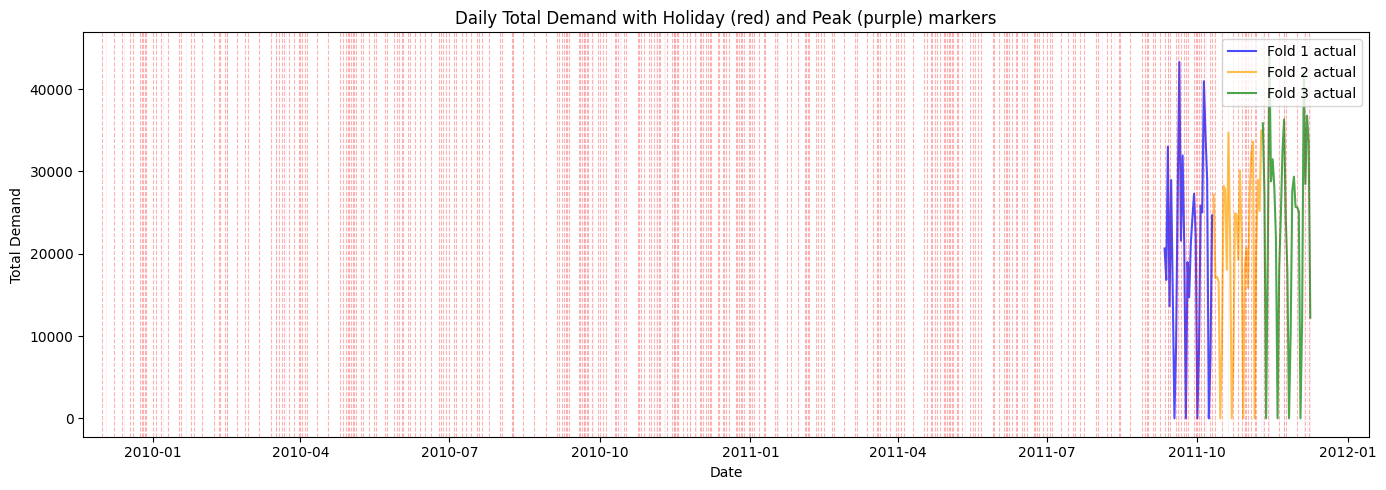

In [21]:
# Visualization: Forecast vs Actual by peak/normal (aggregated)
import matplotlib.pyplot as plt

fold_preds = []
for fold_idx, (train_end, val_start, val_end) in enumerate(splits, start=1):
    val_mask = (panel_df[DATE_COL] >= val_start) & (panel_df[DATE_COL] <= val_end)
    daily_actual = panel_df.loc[val_mask].groupby('date')[TARGET_COL].sum()
    # Get predictions from validation (reuse previous runs)
    fold_preds.append((daily_actual, fold_idx))
    del daily_actual; gc.collect()

# Visualize one fold actual time series
fig, ax = plt.subplots(figsize=(14, 5))
for fold_idx in range(1, 4):
    val_mask = (panel_df[DATE_COL] >= splits[fold_idx-1][1]) & (panel_df[DATE_COL] <= splits[fold_idx-1][2])
    daily = panel_df.loc[val_mask].groupby('date')[TARGET_COL].sum()
    color = ['blue', 'orange', 'green'][fold_idx-1]
    ax.plot(daily.index, daily.values, label=f'Fold {fold_idx} actual', color=color, alpha=0.7)

# Mark holidays
holiday_dates = panel_df[panel_df['is_hari_besar'] == 1]['date'].unique()
for hd in holiday_dates:
    ax.axvline(x=hd, color='red', linestyle='--', alpha=0.3, linewidth=0.8)

# Mark peak days
peak_dates = panel_df[panel_df['is_peak_day'] == 1]['date'].unique()
for pd_ in peak_dates[:50]:
    ax.axvline(x=pd_, color='purple', linestyle=':', alpha=0.2, linewidth=0.5)

ax.set_title('Daily Total Demand with Holiday (red) and Peak (purple) markers')
ax.set_xlabel('Date'); ax.set_ylabel('Total Demand')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Feature importance (subsample 100k non-zero for speed)
nz_mask = panel_df[TARGET_COL] > 0
nz_idx = np.where(nz_mask.to_numpy())[0]
rng = np.random.default_rng(RANDOM_STATE)
samp_idx = rng.choice(nz_idx, size=min(100_000, len(nz_idx)), replace=False)
X_s = panel_df.iloc[samp_idx][ALL_FEATURES].to_numpy(dtype=np.float32, copy=False)
y_s = np.log1p(panel_df.iloc[samp_idx][TARGET_COL].to_numpy()) if USE_LOG_TARGET else panel_df.iloc[samp_idx][TARGET_COL].to_numpy()
ip = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                     tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1,
                     objective='reg:quantileerror', quantile_alpha=QUANTILE_Q_PEAK)
ip.fit(X_s, y_s)
imp = ip.get_booster().get_score(importance_type='gain')
imp_df = pd.DataFrame.from_dict(imp, orient='index', columns=['gain']).sort_values('gain', ascending=False)
imp_df['gain_pct'] = imp_df['gain'] / imp_df['gain'].sum() * 100
imp_df.head(15)


,gain,gain_pct
f34,10.567692,15.210159
f50,3.311743,4.766616
f38,3.264994,4.699331
f14,3.040174,4.375746
f33,2.896034,4.168284
f32,2.860808,4.117583
f37,2.748708,3.956237
f51,2.727854,3.926221
f35,2.608721,3.754753
f42,2.198912,3.164911


In [24]:
print('=== FINAL SUMMARY ===\n')
print(f'Parameters:')
print(f'  QUANTILE_Q_TOP = {QUANTILE_Q_TOP}, QUANTILE_Q_PEAK = {QUANTILE_Q_PEAK}')
print(f'  HOLIDAY_BOOST = {HOLIDAY_BOOST}, PRE_HOLIDAY_BOOST = {PRE_HOLIDAY_BOOST}, PEAK_DAYS_BOOST = {PEAK_DAYS_BOOST}')
print(f'  PEAK_DAYS_PCT = {PEAK_DAYS_PCT}')
print()
print('Boosted results:')
print(results)
print()
print('Peak vs normal:')
print(peak_summary)
print()
print('Quantile buckets:')
print(q_pivot)
print()
print('Segment summary:')
print(seg_summary)

=== FINAL SUMMARY ===

Parameters:
  QUANTILE_Q_TOP = 0.9, QUANTILE_Q_PEAK = 0.95
  HOLIDAY_BOOST = 1.5, PRE_HOLIDAY_BOOST = 0.5, PEAK_DAYS_BOOST = 2.0
  PEAK_DAYS_PCT = 0.05

Boosted results:
             mae     rmse     smape  f1_zero  precision_zero  recall_zero         cls     ofr  oos_rate     fva  threshold  fold
label                                                                                                                           
boosted  19.1254  58.7099  164.4672   0.6557          0.5288       0.8689  40621.6888  0.8131    0.0331 -3.9527        0.1   2.0

Peak vs normal:
  day_type      mae      rmse         cls     ofr
0   normal  15.0168   46.3585  29149.4143  0.8246
1     peak  45.4278  112.9483  11729.8234  0.7669

Quantile buckets:
           mae    rmse       cls   ofr
bucket                                
0-50     35.91   69.35   5828.44  0.86
50-80    63.76  107.52   7869.73  0.82
80-95    93.31  142.24   4778.46  0.91
95-100  150.33  242.69  22402.61  0.74


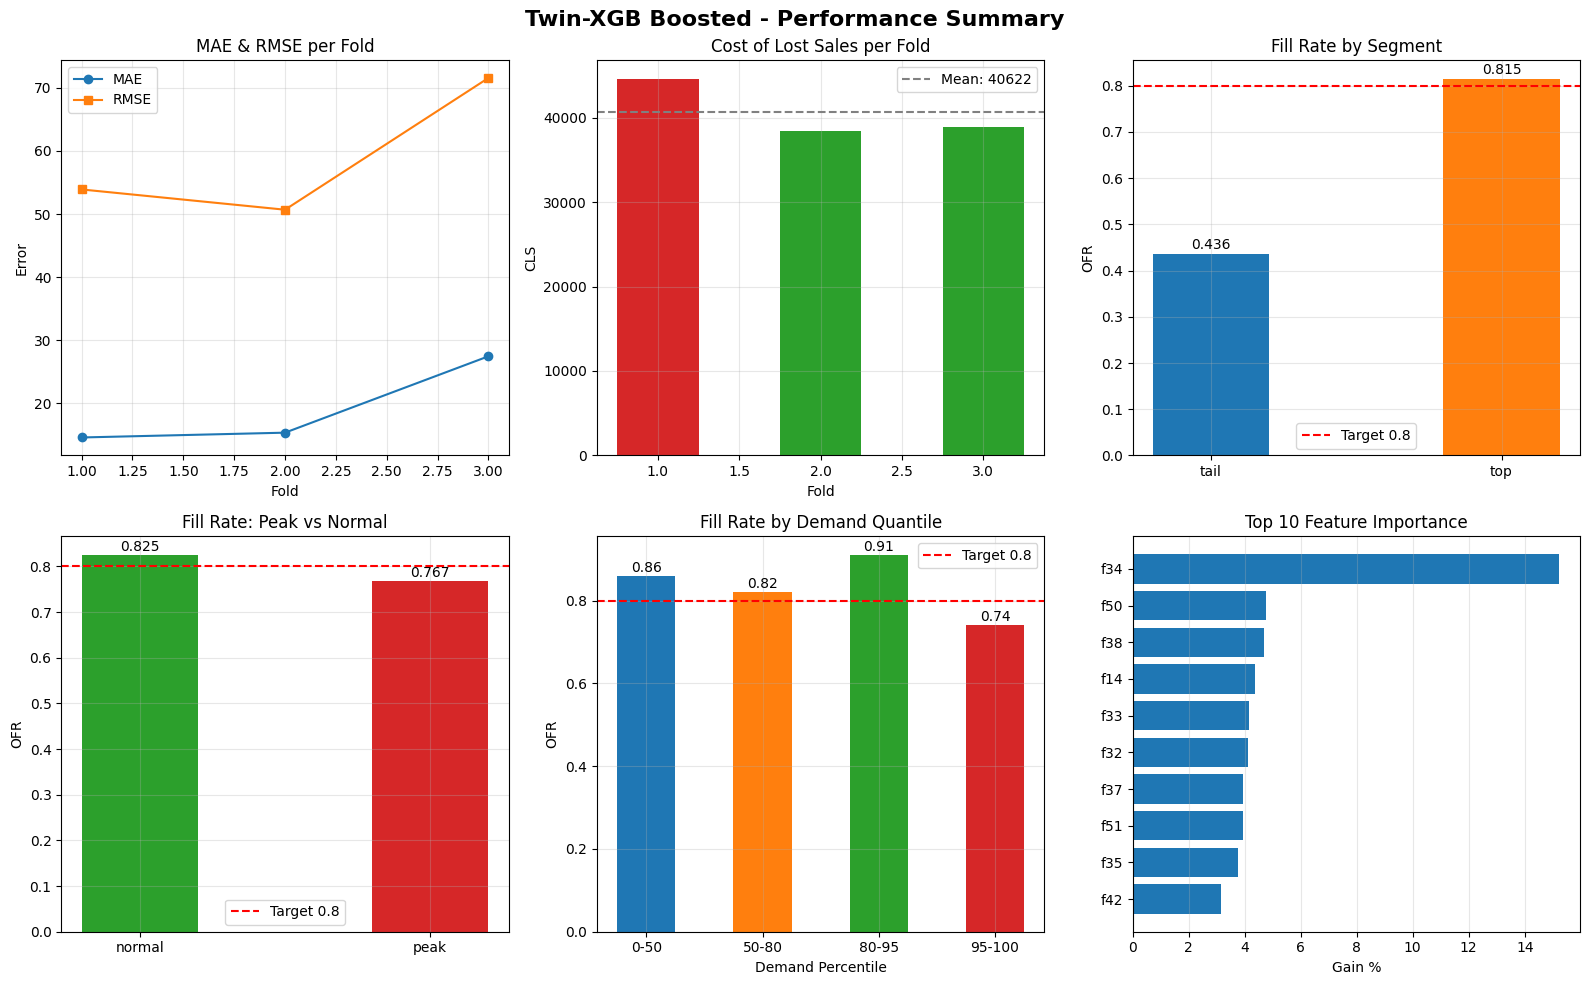

In [25]:
# ============================================================
# Visualization: Forecast Performance Summary
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Twin-XGB Boosted - Performance Summary', fontsize=16, fontweight='bold')

# 1. Fold MAE & RMSE
ax = axes[0, 0]
try:
    ax.plot(df_boosted['fold'], df_boosted['mae'], 'o-', label='MAE', color='#1f77b4')
    ax.plot(df_boosted['fold'], df_boosted['rmse'], 's-', label='RMSE', color='#ff7f0e')
    ax.set_xlabel('Fold'); ax.set_ylabel('Error')
    ax.set_title('MAE & RMSE per Fold')
    ax.legend(); ax.grid(True, alpha=0.3)
except: ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 2. CLS per Fold
ax = axes[0, 1]
try:
    colors = ['#2ca02c' if v <= df_boosted['cls'].mean() else '#d62728' for v in df_boosted['cls']]
    ax.bar(df_boosted['fold'], df_boosted['cls'], color=colors, width=0.5)
    ax.axhline(y=df_boosted['cls'].mean(), color='gray', linestyle='--',
               label=f"Mean: {df_boosted['cls'].mean():.0f}")
    ax.set_xlabel('Fold'); ax.set_ylabel('CLS')
    ax.set_title('Cost of Lost Sales per Fold')
    ax.legend(); ax.grid(True, alpha=0.3)
except: ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 3. Top vs Tail
ax = axes[0, 2]
try:
    ax.bar(seg_summary['segment'], seg_summary['ofr'],
           color=['#1f77b4', '#ff7f0e'], width=0.4)
    ax.axhline(y=0.8, color='red', linestyle='--', label='Target 0.8')
    for i, v in enumerate(seg_summary['ofr']):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
    ax.set_ylabel('OFR'); ax.set_title('Fill Rate by Segment')
    ax.legend(); ax.grid(True, alpha=0.3)
except: ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 4. Peak vs Normal
ax = axes[1, 0]
try:
    bars = ax.bar(peak_summary['day_type'], peak_summary['ofr'],
                  color=['#2ca02c', '#d62728'], width=0.4)
    ax.axhline(y=0.8, color='red', linestyle='--', label='Target 0.8')
    for bar, val in zip(bars, peak_summary['ofr']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center')
    ax.set_ylabel('OFR'); ax.set_title('Fill Rate: Peak vs Normal')
    ax.legend(); ax.grid(True, alpha=0.3)
except: ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 5. Quantile Bucket OFR
ax = axes[1, 1]
try:
    qp = qdf.groupby('bucket')[['mae','rmse','cls','ofr']].mean().round(2).reset_index()
    colors_b = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
    bars = ax.bar(qp['bucket'], qp['ofr'], color=colors_b[:len(qp)], width=0.5)
    ax.axhline(y=0.8, color='red', linestyle='--', label='Target 0.8')
    for bar, val in zip(bars, qp['ofr']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.2f}', ha='center')
    ax.set_xlabel('Demand Percentile'); ax.set_ylabel('OFR')
    ax.set_title('Fill Rate by Demand Quantile')
    ax.legend(); ax.grid(True, alpha=0.3)
except: ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

# 6. Feature Importance (top 10)
ax = axes[1, 2]
try:
    imp = imp_df.head(10)
    ax.barh(range(len(imp)), imp['gain_pct'], color='#1f77b4')
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp.index)
    ax.set_xlabel('Gain %')
    ax.set_title('Top 10 Feature Importance')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()
except: ax.text(0.5, 0.5, 'Data not available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()
